---
title: Intro to programming and training Neural Networks with PyTorch
jupyter:
  jupytext:
    formats: ipynb,qmd
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.19.1
  kernelspec:
    display_name: Python 3 (ipykernel)
    language: python
    name: python3
---



<center><img src="figures/pytorch_logo.png"></center>


## Introduction

* PyTorch is an end-to-end open source platform for ML 
* Allows to easily build and deploy ML powered applications.
* Not only Neural Networks



## PyTorch

* PyTorch is an "optimized tensor library for deep learning"
* Scientific computing, general ML, Neural Networks
* C++/python (we use the latter)
* Easy to implement complex architectures with few lines of code

## Docs: https://docs.pytorch.org/docs

* Installation inscructions (you should be already set up!)
* Tutorials from the groud up
* Reference API
  * Models and Layers
  * Data handling
  * Helper functionalities (utils)

## Other ML/DL libraries

* Tensorflow/Keras
* JAX
* ...
* Most concepts translate across libraries with minor differences

## Some terminology

* A dataset in supervised learning is made of a number of (features, label) pairs
* Example, a dataset of diabetic patients is made of:
    * Features: information describing each patient (weight, height, blood pressure...)
    * Labels: whether each patient is diabetic or not (glucose levels higher or lower than...)
* Each (features, label) pair is also called a _sample_ or _example_. Basically a data point
* Features are also sometimes called _inputs_ when referred to something you feed to a NN
* Labels are compared to the NN's _outputs_ to see how well the network is doing compared to the truth

## What is a tensor

The main variables in PyTorch are tensors:

> A tensor is often thought of as a generalized matrix. That is, it could be a 1-D matrix (a vector), a 3-D matrix (something like a cube of numbers), even a 0-D matrix (a single number), or a higher dimensional structure that is harder to visualize. The dimension of the tensor is called its rank.
>
> Src: https://www.kaggle.com/discussions/getting-started/159424




## What is a tensor

The main variables in TensorFlow are, of course, tensors:

> A tensor is often thought of as a generalized matrix. That is, it could be a 1-D matrix (a vector), a 3-D matrix (something like a cube of numbers), even a 0-D matrix (a single number), or a higher dimensional structure that is harder to visualize. The dimension of the tensor is called its rank.

## PyTorch operates on tensors

> Tensors are a specialized data structure that are very similar to arrays and matrices. In PyTorch, we use tensors to encode the inputs and outputs of a model, as well as the model’s parameters.
> 
> Tensors are similar to NumPy’s ndarrays, except that tensors can run on GPUs or other hardware accelerators.
>
> Src: https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html

## The first step is to build a graph of operations

* NNs are defined in PyTorch as graphs through which the data flows until the final result is produced
* Before we can do any operation on our data (images, etc) we need to build the graph of tensor operations
* When we have a full graph built from input to output, we can run our data (training or testing) through it.

> (PyTorch implements) Over 1200 tensor operations, including arithmetic, linear algebra, matrix manipulation (transposing, indexing, slicing), sampling and more (...)

## Tensors and data are *not* the same thing
* Tensors are, rather, a symbolic representation of the data
* Think about the function $g = f(x)$: as long as we do not assign a value to $x$, we will not have a fully computed $g$
* In this case, $g$ is the output tensor, $x$ the input tensor, $f$ the tensor operation (a Neural Network?)

## Example

* We have a set of color images of size $1000x1000$ pixels (1 megapixel) that we want to use on our NN 
* We define tensors with shape $(n, 1000, 1000, 3)$
    * $n$ is the number of images that we are presenting to our network in one go (a "batch")
    * $1000x1000$: image pixels
    * $3$ is the number of channels (RGB)
    * Grayscale images tensors would have shape $(n, 1000, 1000, 1)$

## One thing to remember when operating on tensors

The dimensions between tensors coming out of the $i$-th node and those going into the $(i+1)$-th node *must* match:

* If each sample in our dataset is made of 10 features, the first (input) layer must accept a tensor of shape $(n, 10)$
* If the first layer in our NN outputs a 3D tensor, the second layer must accept a 3D tensor as input
* Check the documentation to make sure what input-output shapes are allowed ([example](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv1d.html))

## Here's how a NN layer might look like in PyTorch:

* 7 samples in batch
* 784 inputs
* 500 outputs

<center><img src="figures/nn_layer_tboard.png"></center>

## Here is how a model is built and trained in Keras

```python
import torch
import torch.nn as nn


#Multi-layer perceptron (one hidden layer)
model = nn.Sequential()
model.append(nn.Linear(3, 3))
model.append(nn.Sigmoid())
model.append(nn.Linear(3, 1))
model.append(nn.Sigmoid())

#Gradient descent algorithm, Mean Squared Error as Loss function
loss = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for input, target in dataset:
    optimizer.zero_grad()
    output = model(input)
    loss = loss_fn(output, target)
    loss.backward()
    optimizer.step()
...
```

What does each bit do?

## A neural network in Keras is called a Model

The simplest kind of model is of the Sequential kind:

In [3]:
import torch.nn as nn

model = nn.Sequential()
print(list(model.parameters()))

[]


This is an "empty" model, with no layers, no inputs or outputs are defined either.

Adding layer is easy. Let's say we have data for participants to a clinical study. For participant we have recorded: blood pressure, BMI and age.

The participants have been diagnosed as healthy or sick, these will be our labels.

We could define a simple NN that predicts if a participant is healthy or sick as follows:

In [8]:
from tensorflow.keras.layers import Dense
model = Sequential()
model.append(nn.Linear(3, 4))
model.append(nn.Sigmoid())
model.append(nn.Linear(3, 1))
model.append(nn.Sigmoid())

A "Dense" layer is a fully connected layer as the ones we have seen in Multi-layer Perceptrons.
The above is equal to having this network:

<center><img src="figures/simplenet_patient.png"></center>

If we want to see the layers in the Model this far, we can just call:

In [9]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input (Dense)                (None, 4)                 16        
_________________________________________________________________
output (Dense)               (None, 2)                 10        
Total params: 26
Trainable params: 26
Non-trainable params: 0
_________________________________________________________________


Notice the number of parameters, can you tell why 12 and 8 parameters for each layer?

Using "model.add()" keeps stacking layers on top of what we have:

In [10]:
model.add(Dense(units=2, activation=None))
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input (Dense)                (None, 4)                 16        
_________________________________________________________________
output (Dense)               (None, 2)                 10        
_________________________________________________________________
dense_8 (Dense)              (None, 2)                 6         
Total params: 32
Trainable params: 32
Non-trainable params: 0
_________________________________________________________________


One can also declare the model in one go, by passing a list of layers to Sequential() like so:

In [11]:
model = Sequential([
    Dense(units=4, activation='relu', input_dim=3),
    Dense(units=2, activation='softmax'),
    Dense(units=2, activation=None)
])

model.summary()

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_9 (Dense)              (None, 4)                 16        
_________________________________________________________________
dense_10 (Dense)             (None, 2)                 10        
_________________________________________________________________
dense_11 (Dense)             (None, 2)                 6         
Total params: 32
Trainable params: 32
Non-trainable params: 0
_________________________________________________________________


If we want to see the layers in the Model this far, we can just call:

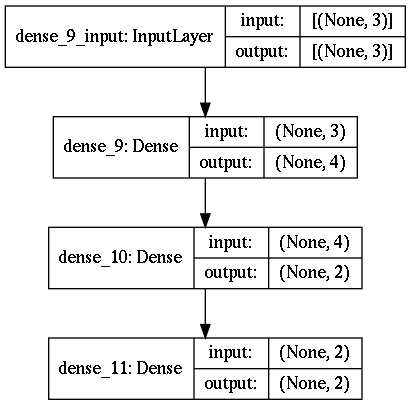

In [13]:
from tensorflow.keras.utils import plot_model

plot_model(model, "figures/simplenet_model.png", show_shapes=True)

## Small exercise

* Can you write code to make a simple NN model on Keras?
* Open the `exercises` jupyter notebook

## Keras layers (https://keras.io/api/layers/)

Common layers (we will cover most of these!)

* Trainable
    * <font color='red'>Dense (fully connected/MLP)</font>
    * <font color='red'>Conv1D (2D/3D)</font>
    * <font color='red'>Recurrent: LSTM/GRU/Bidirectional</font>
    * <font color='red'>Embedding</font>
    * <font color='red'>Lambda (apply your own function)</font>

* Non-trainable
    * <font color='red'>Dropout</font>
    * <font color='red'>Flatten</font>
    * BatchNormalization
    * MaxPooling1D (2D/3D)
    * Merge (add/subtract/concatenate)
    * <font color='red'>Activation (Softmax/ReLU/Sigmoid/...)</font>

## Compiling a model

Once we have defined a model we want to "compile" it

This means chosing a Loss function and an Optimizer (the algorithm that finds the minimum loss possible).

In [14]:
model.compile(optimizer='rmsprop',                    #adaptive learning rate method
              loss='sparse_categorical_crossentropy', #loss function for classification problems with integer labels
              metrics=['accuracy'])                   #the metric doesn't influence the training

model.optimizer.get_config()

{'name': 'RMSprop',
 'learning_rate': 0.001,
 'decay': 0.0,
 'rho': 0.9,
 'momentum': 0.0,
 'epsilon': 1e-07,
 'centered': False}

## Losses (https://keras.io/api/losses/)

These are the functions used to evaluate and train the neural network

Common losses for classification problems:
* CategoricalCrossentropy
* SparseCategoricalCrossentropy
* KLDivergence

Common losses for regression problems:
* MeanSquaredError
* MeanAbsoluteError

## Metrics (https://keras.io/api/metrics/)

Common metrics for classification:
* Accuracy/CategoricalAccuracy (respectively for integer labels or one-hot labels)
* SparseCategoricalCrossentropy/CategoricalCrossentropy (integer/one-hot labels)
* Precision/Recall
* AUC

Common metrics for regression:
* MeanSquaredError
* MeanAbsoluteError

## Metrics (https://keras.io/api/metrics/)

Notice the "metrics" parameter, which accepts a list of values. Multiple metrics can be shown during training.
Metrics are only to visualize how the training is going, they don't have an effect on training itself

In [ ]:
from tensorflow.keras.optimizers import RMSprop
model.compile(optimizer=RMSprop(learning_rate=1.0),   #adaptive learning rate method
              loss='sparse_categorical_crossentropy', #loss function for classification problems with integer labels
              metrics=['accuracy', 'recall'])         #the metric doesn't influence the training

## Optimizers (https://keras.io/api/optimizers/)

* They are algorithms for gradient descent
* A few to choose from:
    * SGD (Stochastic Gradient Descent)
    * RMSprop (Root Mean Square propagation)
    * Adadelta (Adaptive delta)
    * Adam (Adaptive Moment estimation)

<br>
<br>
<br>
<br>
<img src="figures/gradient_descent.png">

## Gradient Descent 

We have seen how gradient descent works:

For each epoch:
* Get predicted $y$ ($ŷ$) for all $N$ samples
* Calculate error (loss)
* Calculate all gradients (backprop)
* Apply gradients to weights
    
Pros/cons:
* Stable procedure
* Guarantees lower error at next step
* Will get stuck at local minimum

<br>
<br>
<br>
<br>
<img src="figures/gradient_descent.png">

## Stochastic Gradient Descent
For each epoch:
* Divide data in batch blocks of size $n < N$
* For each of the $N/n$ blocks:
    * Get predicted $y$ for $n$ samples
    * Calculate partial loss
    * Calculate gradients (backprop)
    * Apply gradients to weights

Pros/cons:
* Noisy gradients
* Error will still go down overall
* Less likely to get stuck at local minimum

<br>
<br>
<br>
<br>
<img src="figures/gradient_descent.png">

## Optimizers (https://keras.io/api/optimizers/)

We need to choose a learning rate to multiply to our gradient. If it is too small, we risk taking too long to get to a minimum
<center><img src="figures/small_lr.png"></center>

## Optimizers (https://keras.io/api/optimizers/)

If it is too large, the network risks becoming unstable, explode

<center><img src="figures/large_lr.png"></center>

Let's test different optimization strategies on Tensorflow playground: http://playground.tensorflow.org

## Optimizers (https://keras.io/api/optimizers/)

Luckily there are algorithms to address these issues:
* Increase descent speed when past gradients agree with current, slow down otherwise (momentum)
* Annealing (decrease learning rate with passing time)
* Different learning rates for different parameters
* Adaptive learning rate based on gradient

<br>
<br>
<br>
<br>
<img src="figures/adaptive_lr.png">

## Optimizers (https://keras.io/api/optimizers/)

* They are algorithms for gradient descent
* A few to choose from:
    * SGD (stochastic gradient descent)
        * One learning rate, fixed
        * Old, but works well with Nesterov momentum
    * RMSprop
        * One learning rate per parameter
        * Adaptive learning rate (divide by squared mean of past gradients)
    * Adadelta (adaptive learning rate)
        * Similar to RMSprop, no need to set initial learning rate
    * Adam (Adaptive moment estimation)
        * Combines pros from RMSprop, Adadelta, works well with most problems

## Optimizers (https://keras.io/api/optimizers/)
<br>
<br>
<center><img src="figures/adam_et_al.png" width=500></center>
<div style="text-align: right">("Adam: A Method for Stochastic Optimization", 2015)</div>

## Training the model: fit() function (https://keras.io/api/models/model_training_apis/)

* We are almost ready to train the model, I swear
* fit() is a method of the Model, actually launches training on a dataset with features and labels
* X_train, y_train: features and labels
* batch: how many samples between each weight update
* epochs: how many times we iterate through the dataset
* validation_data: used to evaluate the model at the end of every epoch, NOT used for training

```python
model.fit(X_train, y_train, validation_data=(X_val, y_val), batch=32, epochs=10)
```

## Training the model: fit() function (https://keras.io/api/models/model_training_apis/)

* Ok, last thing we need is the actual data, then we can train the model

```python
model.fit(X_train, y_train, validation_data=(X_val, y_val), batch=32, epochs=10, validation_data=(X_val, y_val))
```

## What is this validation thing? Do I really need it?

* Yes, yes you do
* Helps understanding if the model is learning anything useful
* Take some of your labelled data, set it aside, call it validation set and don't train on it
* Evaluate model on validation set at the end of each epoch, see if model works on unseen data
* If it works well on training set but not on validation set, you're overfitting

<img src="figures/overfitting_class.png" width=300>

## What is this validation thing? Do I really need it?

* If it works well on training set but not on validation set, you're overfitting
* Validation data is used to adapt hyperparameters, select best models
* Validation data is NOT testing data (more on this later)
* Let's try this on Tensorflow playground: http://playground.tensorflow.org

<img src="figures/early_stopping.png" width=500>

## Ok, can we PLEASE train a NN now?

* Let's generate some artificial data, see what happens
* Classification dataset, 2 classes
* Let's say 10,000 samples, three features per sample
* Random data

In [15]:
import numpy as np

# Generate dummy data
data = np.random.random((10000, 3))
labels = np.random.randint(2, size=(10000, 1))

#let's print the first sample (three floats) and its corresponding label:
print(np.hstack((data[0:10,:], labels[0:10])))

[[0.6392176  0.40886283 0.50866492 0.        ]
 [0.5397015  0.36943619 0.89124325 1.        ]
 [0.1118191  0.99662499 0.9042881  0.        ]
 [0.29591585 0.1842115  0.6554725  1.        ]
 [0.52257299 0.5313839  0.76147972 1.        ]
 [0.5808307  0.17922672 0.88854141 0.        ]
 [0.97551476 0.89447464 0.53643416 0.        ]
 [0.75043782 0.73694224 0.74255941 1.        ]
 [0.53084998 0.79805755 0.03362038 0.        ]
 [0.00647444 0.90807755 0.70146383 1.        ]]


## We have the data, now make the model, compile it, train it

* At the last layer of a classifier use the _softmax_ activation (more on this later)
* Batch size is 32, 10 epochs
* Take 10% of the data, reserve it for validation

In [ ]:
model = Sequential()
model.add(Dense(4, input_dim=3, activation='sigmoid'))
model.add(Dense(3, activation='sigmoid'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train the model, iterating on the data in batches of 32 samples
history = model.fit(data, labels, epochs=10, batch_size=32, validation_split=0.1)

## Let's visualize our training curves

* Plots loss and accuracy for train and validation sets separately

In [16]:
model = Sequential()
model.add(Dense(4, input_dim=3, activation='tanh'))
model.add(Dense(3, activation='tanh'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train the model, iterating on the data in batches of 32 samples
history = model.fit(data, labels, epochs=10, batch_size=32, validation_split=0.1)

2024-05-20 15:04:08.094059: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2024-05-20 15:04:08.113717: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 1999965000 Hz


Epoch 1/10
282/282 [==============================] - 1s 4ms/step - loss: 0.7257 - accuracy: 0.4891 - val_loss: 0.6966 - val_accuracy: 0.5000
Epoch 2/10
282/282 [==============================] - 0s 2ms/step - loss: 0.6948 - accuracy: 0.4967 - val_loss: 0.6953 - val_accuracy: 0.4990
Epoch 3/10
282/282 [==============================] - 0s 2ms/step - loss: 0.6940 - accuracy: 0.5054 - val_loss: 0.6944 - val_accuracy: 0.4890
Epoch 4/10
282/282 [==============================] - 1s 2ms/step - loss: 0.6931 - accuracy: 0.5035 - val_loss: 0.6941 - val_accuracy: 0.4820
Epoch 5/10
282/282 [==============================] - 1s 2ms/step - loss: 0.6931 - accuracy: 0.4998 - val_loss: 0.6942 - val_accuracy: 0.5000
Epoch 6/10
282/282 [==============================] - 1s 2ms/step - loss: 0.6935 - accuracy: 0.4947 - val_loss: 0.6942 - val_accuracy: 0.4940
Epoch 7/10
282/282 [==============================] - 1s 2ms/step - loss: 0.6931 - accuracy: 0.5018 - val_loss: 0.6939 - val_accuracy: 0.4810
Epoch 

In [17]:
%matplotlib inline

import matplotlib.pyplot as plt

def plot_loss_acc(history):
    try:
        plt.plot(history.history['accuracy'])
        plt.plot(history.history['val_accuracy'])
    except:
        plt.plot(history.history['acc'])
        plt.plot(history.history['val_acc'])

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train acc', 'val acc', 'train loss', 'val loss'], loc='upper left')
    plt.show()

## Let's visualize our training curves

* Plots loss and accuracy for train and validation sets separately
* The model didn't learn anything, which makes sense (data is random)

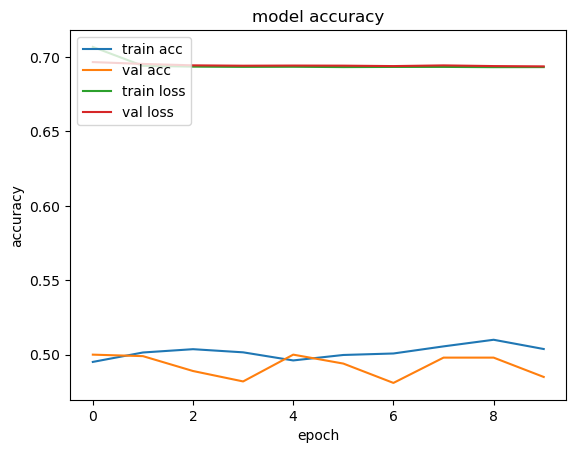

In [18]:
plot_loss_acc(history)

## Do it again, but with data that actually means something

* A XOR function is not linear
* A perceptron is not able to separate XOR classes
* A MLP should be able to

<img src="figures/3-IP-TRUTH-TABLE2.jpg">

Let's generate data that is not just binary, but behaves like it:

* A positive (+) input behaves like a 1
* A negative (-) input behaves like a 0
* -0.5 $\oplus$ 0.2 $\oplus$ -0.1 => 1

In [53]:
# Generate XOR data
data = np.random.random((1000000, 3)) - 0.5
labels = np.zeros((1000000, 1))

labels[np.where(np.logical_xor(np.logical_xor(data[:,0] > 0, data[:,1] > 0), data[:,2] > 0))] = 1

#let's print some data and the corresponding label to check that they match the table above
for x in range(3):
    print("{0: .2f} xor {1: .2f} xor {2: .2f} equals {3:}".format(data[x,0], data[x,1], data[x,2], labels[x,0]))

-0.31 xor -0.38 xor  0.11 equals 1.0
 0.05 xor  0.04 xor  0.09 equals 1.0
 0.33 xor  0.46 xor -0.34 equals 0.0


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
transformed = pca.fit_transform(data)
plt.scatter(transformed[:,0], transformed[:,1], c=labels)

Now let's fit a model to the data:

In [54]:
from keras.layers import LeakyReLU, Dropout
model = Sequential()
model.add(Dense(16, input_dim=3, activation="tanh"))
model.add(Dense(8, activation="tanh"))
model.add(Dense(4, activation="tanh"))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train the model, iterating on the data in batches of 32 samples
history = model.fit(data, labels, epochs=2, batch_size=128, validation_split=0.1, shuffle=True)

Epoch 1/2
7032/7032 [==============================] - 17s 2ms/step - loss: 0.2968 - accuracy: 0.8461 - val_loss: 0.0410 - val_accuracy: 0.9879
Epoch 2/2
7032/7032 [==============================] - 22s 3ms/step - loss: 0.0351 - accuracy: 0.9893 - val_loss: 0.0246 - val_accuracy: 0.9904


In [51]:
from keras.layers import LeakyReLU, Dropout
model = Sequential()
model.add(Dense(16, input_dim=3, activation="tanh"))
model.add(Dense(8, activation="tanh"))
model.add(Dense(4, activation="tanh"))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train the model, iterating on the data in batches of 32 samples
history = model.fit(data, labels, epochs=100, batch_size=128, validation_split=0.1, shuffle=True)

Epoch 1/100
71/71 [==============================] - 1s 7ms/step - loss: 0.6935 - accuracy: 0.5211 - val_loss: 0.6910 - val_accuracy: 0.6130
Epoch 2/100
71/71 [==============================] - 0s 4ms/step - loss: 0.6891 - accuracy: 0.5777 - val_loss: 0.6795 - val_accuracy: 0.7070
Epoch 3/100
71/71 [==============================] - 0s 3ms/step - loss: 0.6717 - accuracy: 0.7058 - val_loss: 0.6493 - val_accuracy: 0.7140
Epoch 4/100
71/71 [==============================] - 0s 3ms/step - loss: 0.6376 - accuracy: 0.7292 - val_loss: 0.6073 - val_accuracy: 0.7560
Epoch 5/100
71/71 [==============================] - 0s 3ms/step - loss: 0.5896 - accuracy: 0.7670 - val_loss: 0.5496 - val_accuracy: 0.7900
Epoch 6/100
71/71 [==============================] - 0s 3ms/step - loss: 0.5298 - accuracy: 0.7979 - val_loss: 0.5007 - val_accuracy: 0.8000
Epoch 7/100
71/71 [==============================] - 0s 4ms/step - loss: 0.4899 - accuracy: 0.7945 - val_loss: 0.4582 - val_accuracy: 0.8150
Epoch 8/100
7

Epoch 59/100
71/71 [==============================] - 0s 4ms/step - loss: 0.0382 - accuracy: 0.9894 - val_loss: 0.0411 - val_accuracy: 0.9860
Epoch 60/100
71/71 [==============================] - 0s 4ms/step - loss: 0.0372 - accuracy: 0.9911 - val_loss: 0.0409 - val_accuracy: 0.9870
Epoch 61/100
71/71 [==============================] - 0s 5ms/step - loss: 0.0345 - accuracy: 0.9919 - val_loss: 0.0397 - val_accuracy: 0.9880
Epoch 62/100
71/71 [==============================] - 0s 5ms/step - loss: 0.0335 - accuracy: 0.9932 - val_loss: 0.0395 - val_accuracy: 0.9870
Epoch 63/100
71/71 [==============================] - 0s 5ms/step - loss: 0.0337 - accuracy: 0.9927 - val_loss: 0.0378 - val_accuracy: 0.9900
Epoch 64/100
71/71 [==============================] - 0s 5ms/step - loss: 0.0307 - accuracy: 0.9953 - val_loss: 0.0368 - val_accuracy: 0.9870
Epoch 65/100
71/71 [==============================] - 0s 6ms/step - loss: 0.0325 - accuracy: 0.9936 - val_loss: 0.0368 - val_accuracy: 0.9850
Epoch 

## XOR data

* Better than random!
* Notice the difference between train and validation curves

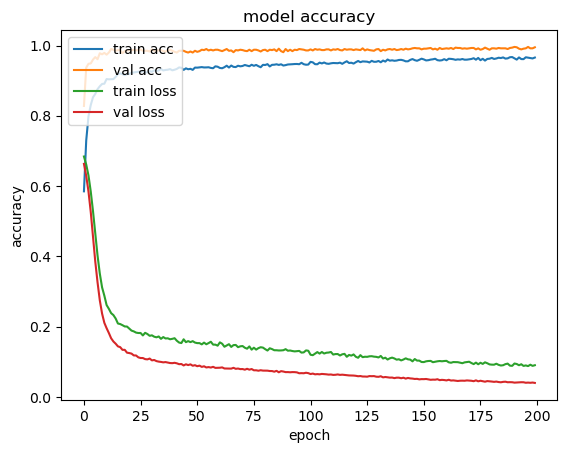

In [44]:
plot_loss_acc(history)

## Exercise: can you do better?

* Check the exercise notebook!

In [ ]:
model = Sequential()
model.add(Dense(4, input_dim=3, activation='sigmoid'))
model.add(Dense(3, activation='sigmoid'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train the model, iterating on the data in batches of 32 samples
history = model.fit(data, labels, epochs=10, batch_size=32, validation_split=0.1)